In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import glob
import numpy as np

In [2]:
original_ds = xr.open_zarr("/home/has/data/sources/icon/ICON312_v1.0.0.zarr")
inference_ds_fmt = "../kempt-liar-eval-domain??.ar.zarr"
files = glob.glob(inference_ds_fmt)
print(f"{len(files)} found")

9 found


In [3]:
def preprocessor(ds):
    ds = ds.isel(start_time=slice(0,5))
    return ds

In [17]:
dss = []
for file in sorted(files):
    dss.append(preprocessor(xr.open_zarr(file)))

/tmp/ipykernel_923354/4011390365.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dss.append(preprocessor(xr.open_zarr(file)))
/tmp/ipykernel_923354/4011390365.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dss.append(preprocessor(xr.open_zarr(file)))
/tmp/ipykernel_923354/4011390365.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dss.append(preprocessor(xr.open_zarr(file)))
/tmp/ipykernel_923354/4011390365.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To sile

In [18]:
# Get domain center coords
domain_centers = []
for d, ds in enumerate(dss):
    lat_center = float(np.rad2deg(original_ds['clat'].sel(cell=ds['grid_index']).mean()))
    lon_center = float(np.rad2deg(original_ds['clon'].sel(cell=ds['grid_index']).mean()))
    domain_centers.append((lat_center, lon_center))

In [19]:
ds = xr.concat(dss, dim='grid_index')

In [20]:
ds['clat'] = original_ds['clat'].sel(cell=ds['grid_index']).drop('cell')
ds = ds.set_coords('clat')

/tmp/ipykernel_923354/2175758050.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds['clat'] = original_ds['clat'].sel(cell=ds['grid_index']).drop('cell')


In [21]:
ds

<xarray.Dataset> Size: 1GB
Dimensions:                    (start_time: 5, elapsed_forecast_duration: 2,
                                grid_index: 4718592, state_feature: 6)
Coordinates:
  * elapsed_forecast_duration  (elapsed_forecast_duration) timedelta64[ns] 16B ...
  * grid_index                 (grid_index) int64 38MB 6099568 ... 3008787
  * start_time                 (start_time) datetime64[ns] 40B 2020-02-01T00:...
  * state_feature              (state_feature) <U8 192B 't_2m' ... 'tqc_dia'
    time                       (grid_index, elapsed_forecast_duration) datetime64[ns] 75MB dask.array<chunksize=(524288, 1), meta=np.ndarray>
    clon                       (grid_index) float64 38MB dask.array<chunksize=(2948019,), meta=np.ndarray>
    clat                       (grid_index) float64 38MB dask.array<chunksize=(2948019,), meta=np.ndarray>
Data variables:
    state                      (start_time, elapsed_forecast_duration, grid_index, state_feature) float32 1GB dask.array<chunksize=(1, 1, 524288, 6), meta=np.ndarray>

loaded


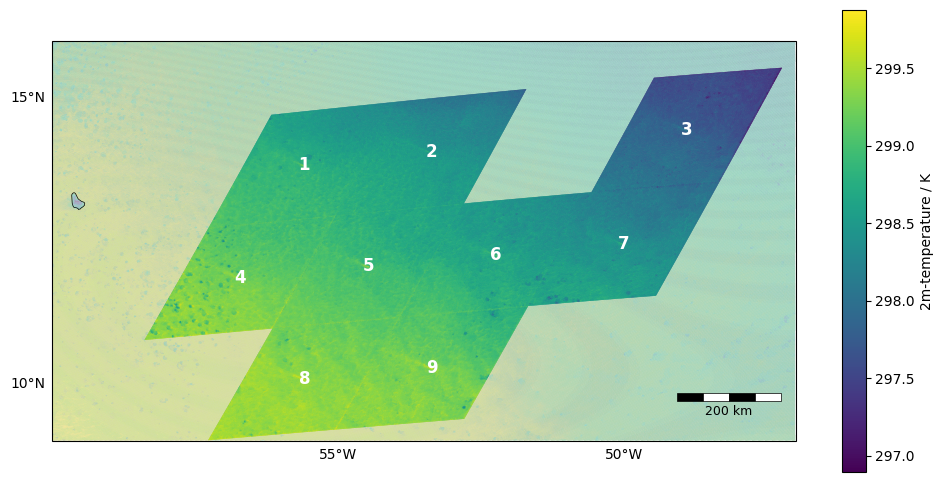

In [24]:
from cartopy.mpl.ticker import LongitudeLocator, LatitudeLocator

import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})


gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0, color='gray')
gl.xlines = False
gl.ylines = False

gl.top_labels = False
gl.right_labels = False

gl.xlocator = LongitudeLocator(2)
gl.ylocator = LatitudeLocator(2)

# ensure tick marks are visible (but no grid lines)
ax.tick_params(which='major', length=4, width=0.6, color='black')

cells_not_covered_by_ml = np.setdiff1d(
    original_ds['cell'].values,
    ds['grid_index'].values,
)
icon_ds_not_covered = original_ds.sel(time=ds.start_time[0], cell=cells_not_covered_by_ml)
icon_ds_not_covered['t_2m'].load()
print("loaded")
sc_icon = ax.scatter(
    np.rad2deg(icon_ds_not_covered['clon']),
    np.rad2deg(icon_ds_not_covered['clat']),
    c=icon_ds_not_covered['t_2m'],
    cmap='viridis',
    s=0.01,
    transform=ccrs.PlateCarree(),
    linewidths=0,
)

sc_ml = ax.scatter(
    np.rad2deg(ds['clon']),
    np.rad2deg(ds['clat']),
    c=ds['state'].isel(start_time=0, elapsed_forecast_duration=0).sel(state_feature='t_2m'),
    cmap='viridis',
    s=0.05,
    transform=ccrs.PlateCarree(),
    linewidths=0,
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.set_extent([-60, -47, 9, 16], crs=ccrs.PlateCarree())

# Add domain center markers
for d,(lat_center, lon_center) in enumerate(domain_centers):
    ax.text(
        lon_center,
        lat_center,
        f'{d+1}',
        color='white',
        fontsize=12,
        fontweight='bold',
        ha='center',
        va='center',
        transform=ccrs.PlateCarree(),
    )


# add a black-white scale bar (two 50 km segments => 100 km total) in the lower-right corner
extent = ax.get_extent(ccrs.PlateCarree())  # returns (x0, x1, y0, y1) in degrees
x0_e, x1_e, y0_e, y1_e = extent
seg_m = 50_000  # length of one segment in meters (50 km)
n_segs = 4      # number of alternating segments -> total = seg_m * n_segs
# choose a latitude near the bottom of the map to compute degrees-per-meter for longitude
lat_for_scale = y0_e + 0.05 * (y1_e - y0_e)
# meters per degree longitude at this latitude (approx)
m_per_deg_lon = 111_320 * np.cos(np.deg2rad(lat_for_scale))
seg_deg = seg_m / m_per_deg_lon
# position the bar a little inset from the right and bottom edges
inset_x_frac = 0.02
inset_y_frac = 0.1
bar_width_deg = seg_deg * n_segs
bar_height_deg = 0.02 * (y1_e - y0_e)
bar_left = x1_e - inset_x_frac * (x1_e - x0_e) - bar_width_deg
bar_bottom = y0_e + inset_y_frac * (y1_e - y0_e)
# draw alternating rectangles
for i in range(n_segs):
    face = 'black' if i % 2 == 0 else 'white'
    rect = plt.Rectangle((bar_left + i * seg_deg, bar_bottom),
                         seg_deg, bar_height_deg,
                         transform=ccrs.PlateCarree(),
                         facecolor=face, edgecolor='black', linewidth=0.5, zorder=5)
    ax.add_patch(rect)
# label the scale (centered) and optional tick labels
ax.text(bar_left + bar_width_deg / 2, bar_bottom - 0.5 * bar_height_deg,
        f"{(seg_m * n_segs) // 1000} km",
        transform=ccrs.PlateCarree(), ha='center', va='top', fontsize=9, zorder=6)

plt.colorbar(sc_ml, ax=ax, orientation='vertical', label='2m-temperature / K')
plt.show()